In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv('accepted_2007_to_2018Q4.csv')

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/2567533633.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('accepted_2007_to_2018Q4.csv')


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [5]:
data.dtypes

id                                             object
member_id                                     float64
loan_amnt                                     float64
funded_amnt                                   float64
funded_amnt_inv                               float64
term                                           object
int_rate                                      float64
installment                                   float64
grade                                          object
sub_grade                                      object
emp_title                                      object
emp_length                                     object
home_ownership                                 object
annual_inc                                    float64
verification_status                            object
issue_d                                        object
loan_status                                    object
pymnt_plan                                     object
url                         

In [6]:
data.isna().sum()

id                                                  0
member_id                                     2260701
loan_amnt                                          33
funded_amnt                                        33
funded_amnt_inv                                    33
term                                               33
int_rate                                           33
installment                                        33
grade                                              33
sub_grade                                          33
emp_title                                      167002
emp_length                                     146940
home_ownership                                     33
annual_inc                                         37
verification_status                                33
issue_d                                            33
loan_status                                        33
pymnt_plan                                         33
url                         

In [7]:
app_type_individual = data[data['application_type'] == 'Individual']
app_type_joint = data[data['application_type'] == 'Joint App']

In [8]:
individual_null_ratio = (app_type_individual.isna().sum()/len(app_type_individual))*100
individual_null_ratio

id                                              0.000000
member_id                                     100.000000
loan_amnt                                       0.000000
funded_amnt                                     0.000000
funded_amnt_inv                                 0.000000
term                                            0.000000
int_rate                                        0.000000
installment                                     0.000000
grade                                           0.000000
sub_grade                                       0.000000
emp_title                                       6.942146
emp_length                                      6.091568
home_ownership                                  0.000000
annual_inc                                      0.000187
verification_status                             0.000000
issue_d                                         0.000000
loan_status                                     0.000000
pymnt_plan                     

In [9]:
individual_columns = app_type_individual.columns
variable = []
drop_variables = []
for i in range(0,len(individual_columns)):
    if individual_null_ratio[i]<=40:
        variable.append(individual_columns[i])
    else: 
        drop_variables.append(individual_columns[i])

In [10]:
app_type_individual_refined = app_type_individual[variable]
print('Features in Original Individual Application Type Dataset ->',app_type_individual.shape[1])
print('Features in Individual Application Type Dataset after missing value analysis ->',app_type_individual_refined.shape[1])

Features in Original Individual Application Type Dataset -> 151
Features in Individual Application Type Dataset after missing value analysis -> 93


In [11]:
individual_refined_null_ratio = (app_type_individual_refined.isna().sum()/len(app_type_individual_refined))*100
individual_refined_null_ratio

id                             0.000000
loan_amnt                      0.000000
funded_amnt                    0.000000
funded_amnt_inv                0.000000
term                           0.000000
int_rate                       0.000000
installment                    0.000000
grade                          0.000000
sub_grade                      0.000000
emp_title                      6.942146
emp_length                     6.091568
home_ownership                 0.000000
annual_inc                     0.000187
verification_status            0.000000
issue_d                        0.000000
loan_status                    0.000000
pymnt_plan                     0.000000
url                            0.000000
purpose                        0.000000
title                          1.049507
zip_code                       0.000047
addr_state                     0.000000
dti                            0.000000
delinq_2yrs                    0.001355
earliest_cr_line               0.001355


In [12]:
app_type_individual_refined.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,1.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,1.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,1.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,1.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDeta

In [13]:
#Variance for policy_code is 0. 
app_type_individual_refined = app_type_individual_refined.drop('policy_code',axis=1)

In [14]:
app_type_individual_refined['loan_amt_funded_amt_flag'] = np.where(app_type_individual_refined['loan_amnt'] == app_type_individual_refined['funded_amnt'],1,0)

In [15]:
app_type_individual_refined.groupby('loan_amt_funded_amt_flag')['id'].count()

loan_amt_funded_amt_flag
0       2064
1    2137894
Name: id, dtype: int64

In [16]:
loan_amt_funded_amt_flag_1 = app_type_individual_refined[app_type_individual_refined['loan_amt_funded_amt_flag'] == 1]

In [17]:
loan_amt_funded_amt_flag_1.groupby('loan_status')['id'].count()

loan_status
Charged Off                                             261873
Current                                                 787189
Default                                                     34
Does not meet the credit policy. Status:Charged Off        717
Does not meet the credit policy. Status:Fully Paid        1891
Fully Paid                                             1055716
In Grace Period                                           7342
Late (16-30 days)                                         3843
Late (31-120 days)                                       19289
Name: id, dtype: int64

In [18]:
loan_amt_funded_amt_flag_0 = app_type_individual_refined[app_type_individual_refined['loan_amt_funded_amt_flag'] == 0]

In [19]:
loan_amt_funded_amt_flag_0.groupby('loan_status')['id'].count()

loan_status
Charged Off                                             342
Current                                                   2
Does not meet the credit policy. Status:Charged Off      44
Does not meet the credit policy. Status:Fully Paid       97
Fully Paid                                             1579
Name: id, dtype: int64

In [20]:
#after detailed anlysis, there isn't much difference between loan_amnt and funded_amnt. even for loan_amnt flag 0 there isn't any clear charge off loans clear seperation.
app_type_individual_refined = app_type_individual_refined.drop('loan_amnt',axis=1)

In [21]:
#Deleting the flag which is created for analytical purposes
app_type_individual_refined = app_type_individual_refined.drop('loan_amt_funded_amt_flag',axis=1)

In [22]:
app_type_individual_refined.head()

,id,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,

In [23]:
app_type_individual_refined['funded_amnt_inv_flag'] = np.where(app_type_individual_refined['funded_amnt'] == app_type_individual_refined['funded_amnt_inv'],1,0)

In [24]:
app_type_individual_refined.groupby('funded_amnt_inv_flag')['id'].count()

funded_amnt_inv_flag
0     146399
1    1993559
Name: id, dtype: int64

In [25]:
funded_amnt_inv_flag_0 = app_type_individual_refined[app_type_individual_refined['funded_amnt_inv_flag'] == 0]

In [26]:
funded_amnt_inv_flag_0['diff_in_amnts'] = funded_amnt_inv_flag_0['funded_amnt'] - funded_amnt_inv_flag_0['funded_amnt_inv']

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/4233811725.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  funded_amnt_inv_flag_0['diff_in_amnts'] = funded_amnt_inv_flag_0['funded_amnt'] - funded_amnt_inv_flag_0['funded_amnt_inv']


In [27]:
bins = [0,100,200,300,600,900,1200]
funded_amnt_inv_flag_0['diff_amnts_bins'] = pd.cut(funded_amnt_inv_flag_0['diff_in_amnts'], bins=bins, labels=['0-100', '100-200', '200-300','300-600','600-900','900-1200'])

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/3956972362.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  funded_amnt_inv_flag_0['diff_amnts_bins'] = pd.cut(funded_amnt_inv_flag_0['diff_in_amnts'], bins=bins, labels=['0-100', '100-200', '200-300','300-600','600-900','900-1200'])


In [28]:
funded_amnt_inv_flag_0.groupby('diff_amnts_bins')['id'].count()

diff_amnts_bins
0-100       103567
100-200       8911
200-300      24906
300-600       3220
600-900        706
900-1200       655
Name: id, dtype: int64

In [29]:
#as the funded_amnt_inv is the total amount commited by the investors towards that loan, I do not think that this variable will be of significant importance towards our model prediction
#dropping the funded_amnt_inv and related variables which are created for analytical purposes
app_type_individual_refined = app_type_individual_refined.drop(['funded_amnt_inv','funded_amnt_inv_flag'],axis=1)

In [30]:
app_type_individual_refined.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,0.00,137

In [31]:
app_type_individual_refined.groupby('term')['id'].count()

term
 36 months    1539983
 60 months     599975
Name: id, dtype: int64

In [32]:
app_type_individual_refined['term'] = app_type_individual_refined['term'].str.extract('(\d+)').astype(int)

In [33]:
app_type_individual_refined.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,0.00,13708.948530,13708.95,11950.00,1758.95

In [34]:
app_type_individual_refined.groupby('term')['id'].count()

term
36    1539983
60     599975
Name: id, dtype: int64

In [35]:
app_type_individual_refined['emp_title'] = app_type_individual_refined['emp_title'].str.upper()

In [36]:
emp_title_unique_values = app_type_individual_refined.groupby('emp_title')['id'].count()
emp_title_unique_values.to_csv('emp_title_unique_results.csv')

In [37]:
uni = app_type_individual_refined['emp_title'].nunique()
uni

425426

In [38]:
#there are over 425426 unique values in emp_title column. it is better to drop such variable
app_type_individual_refined = app_type_individual_refined.drop(['emp_title'],axis=1)

In [39]:
app_type_individual_refined.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,0.00,13708.948530,13708.95,11950.00,1758.95,0.0,0.0,0.0,May-2017,7653.56,May-2017,759.0,755.0,0.0,Individual,0.0,0.0,12798.0,12900.0,0.0,25

In [40]:
app_type_individual_refined.groupby('emp_length')['id'].count()

emp_length
1 year       142364
10+ years    714464
2 years      194839
3 years      172785
4 years      130624
5 years      133536
6 years       98460
7 years       89307
8 years       88634
9 years       76681
< 1 year     167907
Name: id, dtype: int64

In [41]:
app_type_individual_refined.groupby('home_ownership')['id'].count()

home_ownership
ANY             995
MORTGAGE    1031582
NONE             51
OTHER           182
OWN          241623
RENT         865525
Name: id, dtype: int64

In [42]:
values_to_check = ['MORTGAGE','OWN']
app_type_individual_refined['home_ownership'] = np.where(app_type_individual_refined['home_ownership'].str.contains('|'.join(values_to_check)), 1, 0)

In [43]:
app_type_individual_refined.groupby('home_ownership')['id'].count()

home_ownership
0     866753
1    1273205
Name: id, dtype: int64

In [44]:
app_type_individual_refined = app_type_individual_refined.drop('url',axis=1)

In [45]:
app_type_individual_refined.groupby('purpose')['id'].count()

purpose
car                     22898
credit_card            494113
debt_consolidation    1206403
educational               424
home_improvement       140559
house                   13525
major_purchase          47926
medical                 25255
moving                  14535
other                  132162
renewable_energy         1375
small_business          23564
vacation                14865
wedding                  2354
Name: id, dtype: int64

In [46]:
app_type_individual_refined.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36,13.99,123.03,C,C4,10+ years,1,55000.0,Not Verified,Dec-2015,Fully Paid,n,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,564.0,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36,11.99,820.28,C,C1,10+ years,1,65000.0,Not Verified,Dec-2015,Fully Paid,n,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,699.0,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60,14.85,829.90,C,C5,10+ years,1,110000.0,Source Verified,Dec-2015,Current,n,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,679.0,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60,22.45,289.91,F,F1,3 years,1,104433.0,Source Verified,Dec-2015,Fully Paid,n,major_purchase,Major purchase,174xx,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,0.00,11740.500000,11740.50,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,704.0,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36,13.44,405.18,C,C3,4 years,0,34000.0,Source Verified,Dec-2015,Fully Paid,n,debt_consolidation,Debt consolidation,300xx,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,0.00,13708.948530,13708.95,11950.00,1758.95,0.0,0.0,0.0,May-2017,7653.56,May-2017,759.0,755.0,0.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N


In [47]:
app_type_individual_refined = app_type_individual_refined.drop('title',axis=1)

In [48]:
app_type_individual_refined = app_type_individual_refined.drop('zip_code',axis=1)

In [49]:
app_type_individual_refined = app_type_individual_refined.rename(columns={'issue_d':'Origination_Month'})

In [50]:
app_type_individual_refined.groupby('loan_status')['id'].nunique()

loan_status
Charged Off                                             262215
Current                                                 787191
Default                                                     34
Does not meet the credit policy. Status:Charged Off        761
Does not meet the credit policy. Status:Fully Paid        1988
Fully Paid                                             1057295
In Grace Period                                           7342
Late (16-30 days)                                         3843
Late (31-120 days)                                       19289
Name: id, dtype: int64

In [51]:
values_to_check = ['Charged Off','Default','Does not meet the credit policy. Status:Charged Off','Late (16-30 days)','Late (31-120 days)','In Grace Period']
app_type_individual_refined['loan_status'] = np.where(app_type_individual_refined['loan_status'].str.contains('|'.join(values_to_check)), 'Charge Off/Active - Bad Standing', 'Active - Good Standing')

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/3105531864.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  app_type_individual_refined['loan_status'] = np.where(app_type_individual_refined['loan_status'].str.contains('|'.join(values_to_check)), 'Charge Off/Active - Bad Standing', 'Active - Good Standing')


In [52]:
app_type_individual_refined.groupby('loan_status')['id'].count()

loan_status
Active - Good Standing              1869606
Charge Off/Active - Bad Standing     270352
Name: id, dtype: int64

In [53]:
app_type_individual_refined['avg_origination_fico'] = (app_type_individual_refined['fico_range_low'] + app_type_individual_refined['fico_range_high'])/2

In [54]:
bins = [600,650,700,750,800,850,1000]
app_type_individual_refined['fico_low_bins'] = pd.cut(app_type_individual_refined['fico_range_low'], bins=bins, labels=['600-650','650-700','700-750','750-800','800-850','850-1000'])
low_fico_bins_loan_status = app_type_individual_refined.groupby(['fico_low_bins','loan_status'])['id'].count().unstack()
low_fico_bins_loan_status

loan_status,Active - Good Standing,Charge Off/Active - Bad Standing
fico_low_bins,,
600-650,250,112
650-700,1160721,209076
700-750,558279,53679
750-800,131735,6847
800-850,18621,638
850-1000,0,0


In [55]:
bins = [600,650,700,750,800,850,1000]
app_type_individual_refined['fico_high_bins'] = pd.cut(app_type_individual_refined['fico_range_high'], bins=bins, labels=['600-650','650-700','700-750','750-800','800-850','850-1000'])
high_fico_bins_loan_status = app_type_individual_refined.groupby(['fico_high_bins','loan_status'])['id'].count().unstack()
high_fico_bins_loan_status

loan_status,Active - Good Standing,Charge Off/Active - Bad Standing
fico_high_bins,,
600-650,157,74
650-700,1057114,195334
700-750,635872,65817
750-800,151423,8229
800-850,25040,898
850-1000,0,0


In [56]:
bins = [600,650,700,750,800,850,1000]
app_type_individual_refined['fico_avg_bins'] = pd.cut(app_type_individual_refined['avg_origination_fico'], bins=bins, labels=['600-650','650-700','700-750','750-800','800-850','850-1000'])
avg_fico_bins_loan_status = app_type_individual_refined.groupby(['fico_avg_bins','loan_status'])['id'].count().unstack()
avg_fico_bins_loan_status

loan_status,Active - Good Standing,Charge Off/Active - Bad Standing
fico_avg_bins,,
600-650,157,74
650-700,1057114,195334
700-750,635872,65817
750-800,151423,8229
800-850,25040,898
850-1000,0,0


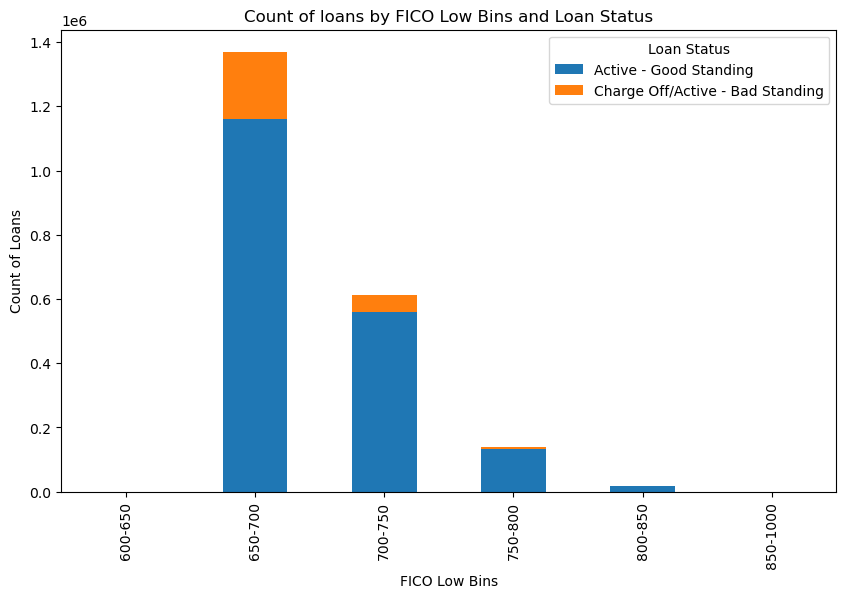

In [57]:
low_fico_bins_loan_status.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Count of loans by FICO Low Bins and Loan Status')
plt.xlabel('FICO Low Bins')
plt.ylabel('Count of Loans')
plt.legend(title='Loan Status')
plt.show()

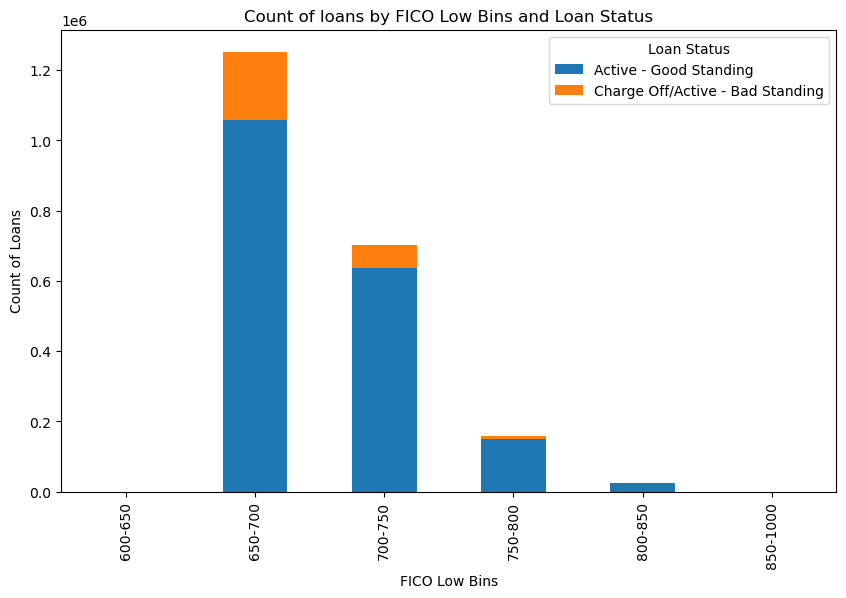

In [58]:
high_fico_bins_loan_status.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Count of loans by FICO Low Bins and Loan Status')
plt.xlabel('FICO Low Bins')
plt.ylabel('Count of Loans')
plt.legend(title='Loan Status')
plt.show()

In [59]:
#drop fico_range_high and use fico_range_low as Origination FICO as this wil give us the worst case scenarios and we will be able to better predict if the loan is good or bad. 
app_type_individual_refined = app_type_individual_refined.drop(['fico_low_bins','fico_high_bins','avg_origination_fico','fico_avg_bins','fico_range_high'],axis=1)

In [60]:
app_type_individual_refined = app_type_individual_refined.drop(['out_prncp_inv','total_pymnt_inv'],axis=1)

In [61]:
app_type_individual_refined = app_type_individual_refined.drop('last_fico_range_high',axis=1)

In [62]:
app_type_individual_refined = app_type_individual_refined.rename(columns={'last_fico_range_low':'Account Management FICO'})

In [63]:
mapping = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
           '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
app_type_individual_refined['emp_length'] = app_type_individual_refined['emp_length'].map(mapping)

In [64]:
app_type_individual_refined['emp_length'].fillna(app_type_individual_refined['emp_length'].mean(), inplace=True)

In [65]:
app_type_individual_refined.groupby('emp_length')['id'].count()

emp_length
0.000000     167907
1.000000     142364
2.000000     194839
3.000000     172785
4.000000     130624
5.000000     133536
5.971495     130357
6.000000      98460
7.000000      89307
8.000000      88634
9.000000      76681
10.000000    714464
Name: id, dtype: int64

In [66]:
app_type_individual_refined.groupby(['debt_settlement_flag','loan_status'])['id'].count()

debt_settlement_flag  loan_status                     
N                     Active - Good Standing              1868694
                      Charge Off/Active - Bad Standing     237653
Y                     Active - Good Standing                  912
                      Charge Off/Active - Bad Standing      32699
Name: id, dtype: int64

In [67]:
app_type_individual_refined.groupby(['disbursement_method','loan_status'])['id'].count()

disbursement_method  loan_status                     
Cash                 Active - Good Standing              1798103
                     Charge Off/Active - Bad Standing     268713
DirectPay            Active - Good Standing                71503
                     Charge Off/Active - Bad Standing       1639
Name: id, dtype: int64

In [68]:
app_type_individual_refined.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,Origination_Month,loan_status,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,Account Management FICO,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36,13.99,123.03,C,C4,10.0,1,55000.0,Not Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,4421.723917,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36,11.99,820.28,C,C1,10.0,1,65000.0,Not Verified,Dec-2015,Active - Good Standing,n,small_business,SD,16.06,1.0,Dec-1999,715.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,25679.660000,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60,14.85,829.90,C,C5,10.0,1,110000.0,Source Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,NJ,17.06,0.0,Sep-2008,785.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,31464.010000,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60,22.45,289.91,F,F1,3.0,1,104433.0,Source Verified,Dec-2015,Active - Good Standing,n,major_purchase,PA,25.37,1.0,Jun-1998,695.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,11740.500000,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36,13.44,405.18,C,C3,4.0,0,34000.0,Source Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,13708.948530,11950.00,1758.95,0.0,0.0,0.0,May-2017,7653.56,May-2017,755.0,0.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N


In [69]:
individual_null_ratio = (app_type_individual_refined.isna().sum()/len(app_type_individual_refined))*100
individual_null_ratio

id                             0.000000
funded_amnt                    0.000000
term                           0.000000
int_rate                       0.000000
installment                    0.000000
grade                          0.000000
sub_grade                      0.000000
emp_length                     0.000000
home_ownership                 0.000000
annual_inc                     0.000187
verification_status            0.000000
Origination_Month              0.000000
loan_status                    0.000000
pymnt_plan                     0.000000
purpose                        0.000000
addr_state                     0.000000
dti                            0.000000
delinq_2yrs                    0.001355
earliest_cr_line               0.001355
fico_range_low                 0.000000
inq_last_6mths                 0.001402
open_acc                       0.001355
pub_rec                        0.001355
revol_bal                      0.000000
revol_util                     0.072525


In [70]:
app_type_individual_refined.isna().sum()

id                                 0
funded_amnt                        0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_length                         0
home_ownership                     0
annual_inc                         4
verification_status                0
Origination_Month                  0
loan_status                        0
pymnt_plan                         0
purpose                            0
addr_state                         0
dti                                0
delinq_2yrs                       29
earliest_cr_line                  29
fico_range_low                     0
inq_last_6mths                    30
open_acc                          29
pub_rec                           29
revol_bal                          0
revol_util                      1552
total_acc                         29
initial_list_status                0
o

In [71]:
app_type_individual_refined.groupby('loan_status')['id'].count()

loan_status
Active - Good Standing              1869606
Charge Off/Active - Bad Standing     270352
Name: id, dtype: int64

In [72]:
app_type_individual_refined.groupby('loan_status')[['collections_12_mths_ex_med','fico_range_low','delinq_2yrs','tot_coll_amt','tot_cur_bal','total_rev_hi_lim','acc_open_past_24mths','avg_cur_bal','mo_sin_old_il_acct']].mean()

,collections_12_mths_ex_med,fico_range_low,delinq_2yrs,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,mo_sin_old_il_acct
loan_status,,,,,,,,,
Active - Good Standing,0.018022,699.319303,0.303632,236.361984,143448.777784,35254.616708,4.431735,13620.589655,126.054568
Charge Off/Active - Bad Standing,0.021970,687.648954,0.353791,239.737265,119043.882263,29023.799563,5.326008,10921.649304,123.171665


In [73]:
tot_coll_amt_nulls = app_type_individual_refined[app_type_individual_refined['tot_coll_amt'].isna()]

In [74]:
tot_coll_amt_nulls.groupby('loan_status')['id'].count()

loan_status
Active - Good Standing              59197
Charge Off/Active - Bad Standing    11079
Name: id, dtype: int64

In [75]:
tot_coll_amt_nulls.groupby('loan_status')[['collections_12_mths_ex_med','acc_now_delinq','fico_range_low','delinq_2yrs','tot_coll_amt','tot_cur_bal','total_rev_hi_lim','acc_open_past_24mths','avg_cur_bal','mo_sin_old_il_acct']].mean()

,collections_12_mths_ex_med,acc_now_delinq,fico_range_low,delinq_2yrs,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,mo_sin_old_il_acct
loan_status,,,,,,,,,,
Active - Good Standing,0.0,0.000068,712.071727,0.147944,NaN,NaN,NaN,3.864993,NaN,NaN
Charge Off/Active - Bad Standing,0.0,0.000000,698.304901,0.173799,NaN,NaN,NaN,4.553904,NaN,NaN


In [76]:
#There are over 70000 rows for which most of the columns are nulls and most of them are active good standing.
#I think instead of imputing these recrods it is best to drop these records. 
#As most of the dropped records are active good standing, I think it is safe. 
app_type_individual_refined_v1 = app_type_individual_refined[~app_type_individual_refined['tot_coll_amt'].isna()]

In [77]:
app_type_individual_refined_v1.shape

(2069682, 82)

In [78]:
app_type_individual_refined.shape

(2139958, 82)

In [79]:
app_type_individual_refined_v1.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,Origination_Month,loan_status,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,Account Management FICO,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,36,13.99,123.03,C,C4,10.0,1,55000.0,Not Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.00,4421.723917,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,Mar-2019,560.0,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,36,11.99,820.28,C,C1,10.0,1,65000.0,Not Verified,Dec-2015,Active - Good Standing,n,small_business,SD,16.06,1.0,Dec-1999,715.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.00,25679.660000,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,Mar-2019,695.0,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
3,66310712,35000.0,60,14.85,829.90,C,C5,10.0,1,110000.0,Source Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,NJ,17.06,0.0,Sep-2008,785.0,0.0,13.0,0.0,7802.0,11.6,17.0,w,15897.65,31464.010000,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Mar-2019,675.0,0.0,Individual,0.0,0.0,301500.0,67300.0,2.0,23192.0,54962.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,N,Cash,N
4,68476807,10400.0,60,22.45,289.91,F,F1,3.0,1,104433.0,Source Verified,Dec-2015,Active - Good Standing,n,major_purchase,PA,25.37,1.0,Jun-1998,695.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.00,11740.500000,10400.00,1340.50,0.0,0.0,0.0,Jul-2016,10128.96,Mar-2018,700.0,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,68426831,11950.0,36,13.44,405.18,C,C3,4.0,0,34000.0,Source Verified,Dec-2015,Active - Good Standing,n,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.00,13708.948530,11950.00,1758.95,0.0,0.0,0.0,May-2017,7653.56,May-2017,755.0,0.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N


In [80]:
app_type_individual_refined_v1.groupby('loan_status')[['inq_last_6mths']].mean()

,inq_last_6mths
loan_status,
Active - Good Standing,0.546300
Charge Off/Active - Bad Standing,0.768603


In [81]:
#filling inq_last_6mths wrt loan status 
app_type_individual_refined_v1['inq_last_6mths'] = app_type_individual_refined_v1.groupby('loan_status')['inq_last_6mths'].transform(lambda x: x.fillna(x.mean()))

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/2234366391.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_type_individual_refined_v1['inq_last_6mths'] = app_type_individual_refined_v1.groupby('loan_status')['inq_last_6mths'].transform(lambda x: x.fillna(x.mean()))


In [82]:
#mean of revol_util is 50% without loan status grouping
app_type_individual_refined_v1['revol_util'].mean()

50.459748018978374

In [83]:
app_type_individual_refined_v1.groupby('loan_status')[['revol_util']].mean()

,revol_util
loan_status,
Active - Good Standing,49.853831
Charge Off/Active - Bad Standing,54.690045


In [84]:
rev_util_isna = app_type_individual_refined_v1[app_type_individual_refined_v1['revol_util'].isna()]
rev_util_isna.groupby('loan_status')['id'].count()

loan_status
Active - Good Standing              1284
Charge Off/Active - Bad Standing     147
Name: id, dtype: int64

In [85]:
#instead of just using the 50.45% which is the global mean for revol_util 
#I think it is best to use the mean grouped by loan status for revol_util 
#(revol_util mean for active good is 49.8) and (revol_util for charge off is at 54.6)
#and we have more number of active good standing for revol_util null records
app_type_individual_refined_v1['revol_util'] = app_type_individual_refined_v1.groupby('loan_status')['revol_util'].transform(lambda x: x.fillna(x.mean()))

/var/folders/9h/ysj088sj0_l16hcjkk4qr1bw0000gn/T/ipykernel_85986/2891699945.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_type_individual_refined_v1['revol_util'] = app_type_individual_refined_v1.groupby('loan_status')['revol_util'].transform(lambda x: x.fillna(x.mean()))


In [86]:
app_type_individual_refined_v1['revol_util'].isna().sum()

0

In [87]:
app_type_individual_refined_v1.groupby(['pymnt_plan','loan_status'])['id'].count()

pymnt_plan  loan_status                     
n           Active - Good Standing              1809878
            Charge Off/Active - Bad Standing     259273
y           Active - Good Standing                  531
Name: id, dtype: int64

In [88]:
#we do not have any Charge Offs for payment plan y. 
# there are 1-2% applications for payment plan y. there is not a lot of feature importance here. 
# it is best to remove this feature
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('pymnt_plan',axis=1)

In [89]:
app_type_individual_refined_v1.groupby(['verification_status','loan_status'])['id'].count()

verification_status  loan_status                     
Not Verified         Active - Good Standing              615089
                     Charge Off/Active - Bad Standing     56222
Source Verified      Active - Good Standing              726161
                     Charge Off/Active - Bad Standing    107932
Verified             Active - Good Standing              469159
                     Charge Off/Active - Bad Standing     95119
Name: id, dtype: int64

In [90]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('last_pymnt_d',axis=1)

In [91]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['Origination_Month','last_credit_pull_d'],axis=1)

In [92]:
app_type_individual_refined_v1['avg_cur_bal'].mean()

13282.486286867843

In [93]:
app_type_individual_refined_v1.groupby(['home_ownership','loan_status'])['avg_cur_bal'].mean()

home_ownership  loan_status                     
0               Active - Good Standing               5170.120710
                Charge Off/Active - Bad Standing     4865.032491
1               Active - Good Standing              19111.232480
                Charge Off/Active - Bad Standing    16148.055449
Name: avg_cur_bal, dtype: float64

In [94]:
null_avg_cur_bal = app_type_individual_refined_v1[app_type_individual_refined_v1['avg_cur_bal'].isna()]
null_avg_cur_bal.groupby(['home_ownership','loan_status'])['id'].count()

home_ownership  loan_status                     
0               Active - Good Standing              36
                Charge Off/Active - Bad Standing     3
1               Active - Good Standing              18
                Charge Off/Active - Bad Standing     3
Name: id, dtype: int64

In [95]:
null_avg_cur_bal = app_type_individual_refined_v1[app_type_individual_refined_v1['avg_cur_bal'].isna()]
null_avg_cur_bal.groupby(['home_ownership','loan_status'])['fico_range_low'].mean()

home_ownership  loan_status                     
0               Active - Good Standing              703.194444
                Charge Off/Active - Bad Standing    721.666667
1               Active - Good Standing              703.333333
                Charge Off/Active - Bad Standing    708.333333
Name: fico_range_low, dtype: float64

In [96]:
app_type_individual_refined_v1['avg_cur_bal'] = app_type_individual_refined_v1.groupby(['home_ownership','loan_status'])['avg_cur_bal'].transform(lambda x: x.fillna(x.mean()))

In [97]:
app_type_individual_refined_v1['mo_sin_old_il_acct'].mean()

125.6935362646559

In [98]:
app_type_individual_refined_v1.groupby(['home_ownership','loan_status'])['mo_sin_old_il_acct'].mean()

home_ownership  loan_status                     
0               Active - Good Standing              115.928764
                Charge Off/Active - Bad Standing    115.458764
1               Active - Good Standing              132.465032
                Charge Off/Active - Bad Standing    129.690902
Name: mo_sin_old_il_acct, dtype: float64

In [99]:
null_mo_sin_old_il_acct = app_type_individual_refined_v1[app_type_individual_refined_v1['mo_sin_old_il_acct'].isna()]
null_mo_sin_old_il_acct.groupby(['home_ownership','loan_status'])['id'].count()

home_ownership  loan_status                     
0               Active - Good Standing              33087
                Charge Off/Active - Bad Standing     5078
1               Active - Good Standing              23343
                Charge Off/Active - Bad Standing     3095
Name: id, dtype: int64

In [100]:
app_type_individual_refined_v1['mo_sin_old_il_acct'] = app_type_individual_refined_v1.groupby(['home_ownership','loan_status'])['mo_sin_old_il_acct'].transform(lambda x: x.fillna(x.mean()))

In [101]:
#as we already have revolving_utilization I do not think revol_bal ($ value) makes sense. $ value can vary a lot from person to person
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('revol_bal',axis=1)

In [102]:
app_type_individual_refined_v1.groupby(['initial_list_status','loan_status'])['id'].count()

initial_list_status  loan_status                     
f                    Active - Good Standing               536907
                     Charge Off/Active - Bad Standing     100132
w                    Active - Good Standing              1273502
                     Charge Off/Active - Bad Standing     159141
Name: id, dtype: int64

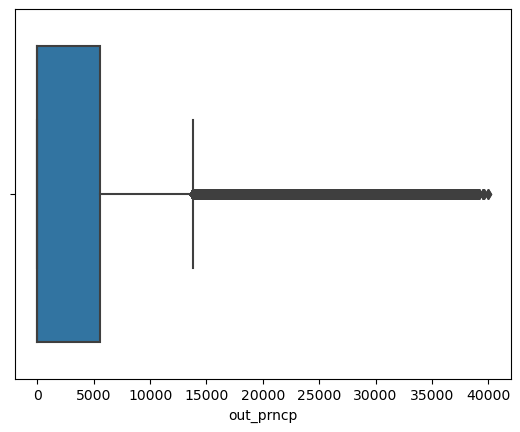

In [103]:
sns.boxplot(x=app_type_individual_refined_v1['out_prncp'])
plt.show()

In [104]:
app_type_individual_refined_v1['out_prncp_%'] = (app_type_individual_refined_v1['out_prncp']/app_type_individual_refined_v1['funded_amnt'])*100

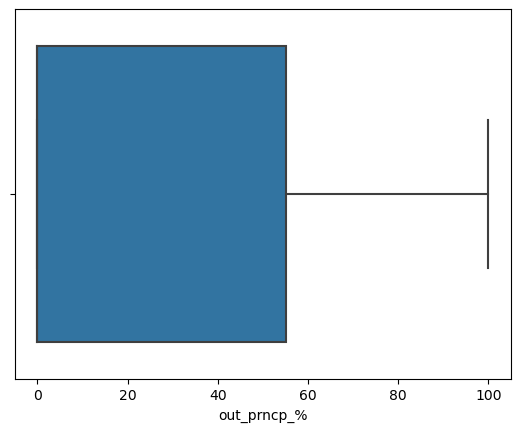

In [105]:
sns.boxplot(x=app_type_individual_refined_v1['out_prncp_%'])
plt.show()

In [106]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('out_prncp',axis=1)

In [107]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('total_rec_prncp',axis=1)

In [108]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('application_type',axis=1)

In [109]:
#I do not think the dollar values for total payment and total interest received will make sense in our model output prediction
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['total_pymnt','total_rec_int'],axis=1)

In [110]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['last_pymnt_amnt'],axis=1)

In [111]:
#total_bc_limit - Total bankcard high credit/credit limit
#bc_open_to_buy - Total open to buy on revolving bankcards.
#bc_util - Ratio of total current balance to high credit/credit limit for all bankcard accounts.
#all the above three are inter-related, it is best to use the bc_util instead of using the dollor amounts used for the same calculation

app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['total_bc_limit','bc_open_to_buy'],axis=1)

In [112]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['total_rev_hi_lim'],axis=1)

In [113]:
app_type_individual_refined_v1['tot_cur_bal_flag'] = np.where(app_type_individual_refined_v1['tot_hi_cred_lim'] > app_type_individual_refined_v1['tot_cur_bal'],1,0)

In [114]:
app_type_individual_refined_v1.groupby(['tot_cur_bal_flag','loan_status'])['id'].count()

tot_cur_bal_flag  loan_status                     
0                 Active - Good Standing                32389
                  Charge Off/Active - Bad Standing       5211
1                 Active - Good Standing              1778020
                  Charge Off/Active - Bad Standing     254062
Name: id, dtype: int64

In [115]:
app_type_individual_refined_v1.groupby('loan_status')['tot_cur_bal'].mean()

loan_status
Active - Good Standing              143448.777784
Charge Off/Active - Bad Standing    119043.882263
Name: tot_cur_bal, dtype: float64

In [116]:
#tot_cur_bal/tot_hi_cred_lim
app_type_individual_refined_v1['total_credit_utlization'] = (app_type_individual_refined_v1['tot_cur_bal'] / app_type_individual_refined_v1['tot_hi_cred_lim']) * 100

In [117]:
total_credit_util_110 = app_type_individual_refined_v1[app_type_individual_refined_v1['total_credit_utlization'] > 110]

In [118]:
total_credit_util_110.shape

(12533, 71)

In [119]:
total_credit_util_110.groupby(['loan_status'])['id'].count()

loan_status
Active - Good Standing              10873
Charge Off/Active - Bad Standing     1660
Name: id, dtype: int64

In [120]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['tot_cur_bal_flag','total_credit_utlization'],axis=1)

In [121]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop(['tot_cur_bal','tot_hi_cred_lim'],axis=1)

In [122]:
app_type_individual_refined_v1 = app_type_individual_refined_v1.drop('hardship_flag',axis=1)

In [123]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['verification_status'] = label_encoder.fit_transform(app_type_individual_refined_v1['verification_status'])

In [124]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['loan_status'] = label_encoder.fit_transform(app_type_individual_refined_v1['loan_status'])

In [125]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['initial_list_status'] = label_encoder.fit_transform(app_type_individual_refined_v1['initial_list_status'])

In [126]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['grade'] = label_encoder.fit_transform(app_type_individual_refined_v1['grade'])

In [127]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['disbursement_method'] = label_encoder.fit_transform(app_type_individual_refined_v1['disbursement_method'])

In [128]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
app_type_individual_refined_v1['debt_settlement_flag'] = label_encoder.fit_transform(app_type_individual_refined_v1['debt_settlement_flag'])

In [129]:
mapping = {'A1':11,'A2':12,'A3':13,'A4':14,'A5':15,'B1':21,'B2':22,'B3':23,'B4':24,'B5':25,'C1':31,'C2':32,'C3':33,
          'C4':34,'C5':36,'D1':41,'D2':42,'D3':43,'D4':44,'D5':45,'E1':51,'E2':52,'E3':53,'E4':54,'E5':55,
          'F1':61,'F2':62,'F3':63,'F4':64,'F5':65,'G1':71,'G2':72,'G3':73,'G4':74,'G5':75}
app_type_individual_refined_v1['sub_grade'] = app_type_individual_refined_v1['sub_grade'].map(mapping)

In [130]:
purpose_count = app_type_individual_refined_v1.groupby(['loan_status','purpose'])['id'].count().unstack(fill_value=0)
result_loan_status_percentage = purpose_count.div(purpose_count.sum(axis=0), axis=1) * 100
result_loan_status_percentage

purpose,car,credit_card,debt_consolidation,educational,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation,wedding
loan_status,,,,,,,,,,,,,,
0,90.584996,89.778843,86.3722,100.0,88.920006,88.361027,88.366226,86.860831,84.996342,87.700734,84.659091,81.320864,88.471512,85.503964
1,9.415004,10.221157,13.6278,0.0,11.079994,11.638973,11.633774,13.139169,15.003658,12.299266,15.340909,18.679136,11.528488,14.496036


In [131]:
purpose_count = app_type_individual_refined_v1.groupby(['loan_status','purpose'])['id'].count().unstack(fill_value=0)
result_loan_status_percentage = purpose_count.div(purpose_count.sum(axis=0), axis=1) * 100
result_loan_status_percentage

purpose,car,credit_card,debt_consolidation,educational,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation,wedding
loan_status,,,,,,,,,,,,,,
0,90.584996,89.778843,86.3722,100.0,88.920006,88.361027,88.366226,86.860831,84.996342,87.700734,84.659091,81.320864,88.471512,85.503964
1,9.415004,10.221157,13.6278,0.0,11.079994,11.638973,11.633774,13.139169,15.003658,12.299266,15.340909,18.679136,11.528488,14.496036


In [132]:
app_type_individual_refined_v1['purpose'] = app_type_individual_refined_v1['purpose'].map({
    'car':'Automobile',
    'credit_card': 'Personal',
    'debt_consolidation': 'Debt',
    'educational': 'Miscellenuous',
    'home_improvement': 'Home',
    'house': 'Home',
    'major_purchase': 'Personal',
    'medical': 'Health',
    'moving': 'Other',
    'other': 'Other',
    'renewable_energy': 'Miscellenuous',
    'small_business': 'Business',
    'vacation': 'Personal',
    'wedding': 'Personal'
})

In [133]:
purpose_count = app_type_individual_refined_v1.groupby(['loan_status','purpose'])['id'].count().unstack(fill_value=0)
result_loan_status_percentage = purpose_count.div(purpose_count.sum(axis=0), axis=1) * 100
result_loan_status_percentage

purpose,Automobile,Business,Debt,Health,Home,Miscellenuous,Other,Personal
loan_status,,,,,,,,
0,90.584996,81.320864,86.3722,86.860831,88.871755,84.683955,87.435998,89.621128
1,9.415004,18.679136,13.6278,13.139169,11.128245,15.316045,12.564002,10.378872


In [134]:
app_type_individual_refined_v1.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,initial_list_status,total_rec_late_fee,recoveries,collection_recovery_fee,Account Management FICO,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,total_bal_ex_mort,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,out_prncp_%
0,68407277,3600.0,36,13.99,123.03,2,34,10.0,1,55000.0,0,0,Debt,PA,5.91,0.0,Aug-2003,675.0,1.0,7.0,0.0,29.7,13.0,1,0.0,0.0,0.0,560.0,0.0,0.0,722.0,4.0,20701.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,7746.0,13734.0,0,0,0.000000
1,68355089,24700.0,36,11.99,820.28,2,31,10.0,1,65000.0,0,0,Business,SD,16.06,1.0,Dec-1999,715.0,4.0,22.0,0.0,19.2,38.0,1,0.0,0.0,0.0,695.0,0.0,0.0,0.0,4.0,9733.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,39475.0,24667.0,0,0,0.000000
3,66310712,35000.0,60,14.85,829.90,2,36,10.0,1,110000.0,1,0,Debt,NJ,17.06,0.0,Sep-2008,785.0,0.0,13.0,0.0,11.6,17.0,1,0.0,0.0,0.0,675.0,0.0,0.0,0.0,2.0,23192.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,52226.0,18000.0,0,0,45.421857
4,68476807,10400.0,60,22.45,289.91,5,61,3.0,1,104433.0,1,0,Personal,PA,25.37,1.0,Jun-1998,695.0,3.0,12.0,0.0,64.5,35.0,1,0.0,0.0,0.0,700.0,0.0,0.0,0.0,10.0,27644.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,95768.0,88097.0,0,0,0.000000
5,68426831,11950.0,36,13.44,405.18,2,33,4.0,0,34000.0,1,0,Debt,GA,10.20,0.0,Oct-1987,690.0,0.0,5.0,0.0,68.4,6.0,1,0.0,0.0,0.0,755.0,0.0,0.0,0.0,0.0,2560.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,12798.0,4000.0,0,0,0.000000


In [158]:
Q1 = app_type_individual_refined_v1['total_bal_ex_mort'].quantile(0.25)
Q3 = app_type_individual_refined_v1['total_bal_ex_mort'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers based on the IQR method
outliers_indices = app_type_individual_refined_v1[(app_type_individual_refined_v1['total_bal_ex_mort'] > Q1 - 1.5 * IQR) & (app_type_individual_refined_v1['total_bal_ex_mort'] < Q3 + 1.5 * IQR)]
outliers_indices.groupby('loan_status')['id'].count()

loan_status
0    1699891
1     245809
Name: id, dtype: int64

In [159]:
outliers_indices.shape

(1945700, 66)

In [156]:
app_type_individual_refined_v1.shape

(2069682, 66)

In [172]:
from scipy.stats import zscore 
z_scores = zscore(app_type_individual_refined_v1['total_bal_ex_mort'])
threshold = 3
outliers = (z_scores > threshold) | (z_scores < -threshold)
app_type_individual_refined_v1['outliers_total_bal_ex_mort'] = outliers
app_type_individual_refined_v1.groupby('outliers_total_bal_ex_mort')['id'].count()

outliers_total_bal_ex_mort
False    2031437
True       38245
Name: id, dtype: int64

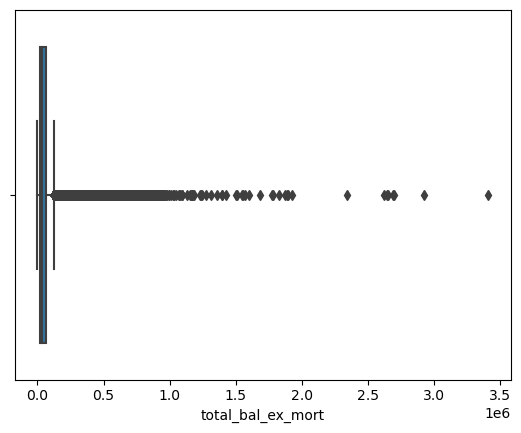

In [144]:
sns.boxplot(x=app_type_individual_refined_v1['total_bal_ex_mort'])
plt.show()

In [135]:
app_type_individual_refined_v1.shape

(2069682, 66)

In [136]:
app_type_individual_refined_v1.groupby(['debt_settlement_flag','loan_status'])['id'].count()

debt_settlement_flag  loan_status
0                     0              1809497
                      1               226912
1                     0                  912
                      1                32361
Name: id, dtype: int64

In [137]:
app_type_individual_refined_v1.groupby('disbursement_method')['id'].count()

disbursement_method
0    1996540
1      73142
Name: id, dtype: int64

In [138]:
app_type_individual_refined_v1.head()

,id,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,initial_list_status,total_rec_late_fee,recoveries,collection_recovery_fee,Account Management FICO,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,total_bal_ex_mort,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,out_prncp_%
0,68407277,3600.0,36,13.99,123.03,2,34,10.0,1,55000.0,0,0,Debt,PA,5.91,0.0,Aug-2003,675.0,1.0,7.0,0.0,29.7,13.0,1,0.0,0.0,0.0,560.0,0.0,0.0,722.0,4.0,20701.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,7746.0,13734.0,0,0,0.000000
1,68355089,24700.0,36,11.99,820.28,2,31,10.0,1,65000.0,0,0,Business,SD,16.06,1.0,Dec-1999,715.0,4.0,22.0,0.0,19.2,38.0,1,0.0,0.0,0.0,695.0,0.0,0.0,0.0,4.0,9733.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,39475.0,24667.0,0,0,0.000000
3,66310712,35000.0,60,14.85,829.90,2,36,10.0,1,110000.0,1,0,Debt,NJ,17.06,0.0,Sep-2008,785.0,0.0,13.0,0.0,11.6,17.0,1,0.0,0.0,0.0,675.0,0.0,0.0,0.0,2.0,23192.0,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,2.0,NaN,0.0,4.0,5.0,8.0,10.0,2.0,10.0,13.0,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,52226.0,18000.0,0,0,45.421857
4,68476807,10400.0,60,22.45,289.91,5,61,3.0,1,104433.0,1,0,Personal,PA,25.37,1.0,Jun-1998,695.0,3.0,12.0,0.0,64.5,35.0,1,0.0,0.0,0.0,700.0,0.0,0.0,0.0,10.0,27644.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,95768.0,88097.0,0,0,0.000000
5,68426831,11950.0,36,13.44,405.18,2,33,4.0,0,34000.0,1,0,Debt,GA,10.20,0.0,Oct-1987,690.0,0.0,5.0,0.0,68.4,6.0,1,0.0,0.0,0.0,755.0,0.0,0.0,0.0,0.0,2560.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,NaN,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,12798.0,4000.0,0,0,0.000000


In [139]:
data_numerical = pd.DataFrame()
data_categorical = pd.DataFrame()
for i in app_type_individual_refined_v1.columns:
    if (app_type_individual_refined_v1[i].dtype == 'float64') or (app_type_individual_refined_v1[i].dtype == 'int64') or (app_type_individual_refined_v1[i].dtype == 'uint8'):
        data_numerical[i] = app_type_individual_refined_v1[i]
    else:
        data_categorical[i] = app_type_individual_refined_v1[i]

In [140]:
data_numerical = data_numerical.drop(['percent_bc_gt_75','pct_tl_nvr_dlq','num_tl_120dpd_2m','mths_since_recent_inq','mths_since_recent_bc','bc_util'],axis=1)

In [141]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame
# Split the data into features (X) and target variable (y)
X = data_numerical.drop('loan_status',axis=1) # Features
column_to_exclude = 'loan_status'
y = data_numerical[[col for col in data_numerical.columns if col == column_to_exclude]]  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the XGBoost model
model_xgb = xgb.XGBClassifier() 
model_xgb.fit(X_train, y_train)

# Get feature importances
feature_importances_xgb = model_xgb.feature_importances_

# Display or use the feature importances
for feature, importance in zip(X_train.columns, feature_importances_xgb):
    print(f"{feature}: {importance*100}")

funded_amnt: 0.15209884149953723
term: 0.9149841964244843
int_rate: 0.09738118387758732
installment: 0.04341786552686244
grade: 0.1047723344527185
sub_grade: 0.1285973470658064
emp_length: 0.21819628309458494
home_ownership: 0.07950689177960157
annual_inc: 0.05603274912573397
verification_status: 0.10167518630623817
dti: 0.11082574492320418
delinq_2yrs: 0.044043909292668104
fico_range_low: 0.06505805649794638
inq_last_6mths: 0.030890811467543244
open_acc: 0.023517769295722246
pub_rec: 0.02484380966052413
revol_util: 0.05786956171505153
total_acc: 0.03520150494296104
initial_list_status: 0.1483033294789493
total_rec_late_fee: 0.15376965748146176
recoveries: 91.42776727676392
collection_recovery_fee: 0.0
Account Management FICO: 3.0518686398863792
collections_12_mths_ex_med: 0.01538060896564275
acc_now_delinq: 0.02968025510199368
tot_coll_amt: 0.023326741938944906
acc_open_past_24mths: 0.0290393567411229
avg_cur_bal: 0.03157127648591995
chargeoff_within_12_mths: 0.02420075616100803
delin

In [142]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Assuming df is your DataFrame
# Split the data into features (X) and target variable (y)
X = data_numerical.drop(['loan_status','mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op','num_rev_accts','sub_grade'],axis=1) # Features
column_to_exclude = 'loan_status'
y = data_numerical['loan_status'] # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

KeyboardInterrupt: 

In [ ]:
X.head()

In [ ]:
X.isna().sum()

In [ ]:
sns.boxplot(x=app_type_individual_refined_v1['bc_util'])
plt.show()

In [ ]:
Q1 = app_type_individual_refined_v1['tot_hi_cred_lim'].quantile(0.25)
Q3 = app_type_individual_refined_v1['tot_hi_cred_lim'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers based on the IQR method
outliers_indices = app_type_individual_refined_v1[(app_type_individual_refined_v1['tot_hi_cred_lim'] < Q1 - 1.5 * IQR) | (app_type_individual_refined_v1['tot_hi_cred_lim'] > Q3 + 1.5 * IQR)]
outliers_indices.shape

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame
# Remove non-numeric columns if needed
numeric_columns = app_type_individual_refined.select_dtypes(include=['int64', 'float64']).columns

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=len(numeric_columns), ncols=1, figsize=(8, 4 * len(numeric_columns)))
fig.subplots_adjust(hspace=0.5)

# Plot box plots for each numeric column
for i, column in enumerate(numeric_columns):
    sns.boxplot(x=app_type_individual_refined[column], ax=axes[i])
    axes[i].set_title(f'Boxplot for {column}')

plt.show()

In [ ]:
bins = [0,5000,10000,20000,50000,100000,150000,200000,250000,300000,400000,500000,600000,700000,800000]
app_type_individual_refined['tot_cur_bal_bins'] = pd.cut(app_type_individual_refined['tot_cur_bal'], bins=bins, labels=['0-5000','5000-10000','10000-20000','20000-50000','50000-100000','100000-150000','150000-200000','200000-250000','250000-300000','300000-400000','400000-500000','500000-600000','600000-700000','700000-800000'])
high_fico_bins_loan_status = app_type_individual_refined.groupby(['tot_cur_bal_bins','loan_status'])['id'].count().unstack()
high_fico_bins_loan_status